# Brain Tumor Classification using XGBoost

This notebook implements different approaches for brain tumor classification:
1. PCA + XGBoost
2. VGG16 + XGBoost
3. Raw + XGBoost

In [11]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

plt.style.use('default')
sns.set_palette("husl")

In [12]:
# Configuration
TRAIN_DIR = r"C:\Users\vijay\Downloads\archive (1)\Training"
TEST_DIR  = r"C:\Users\vijay\Downloads\archive (1)\Testing"

IMG_SIZE = (128, 128)  
RANDOM_STATE = 42
TRAINING_FRACTIONS = [0.2, 0.4, 0.6, 0.8]

XGBOOST_PARAMS = {
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
    'n_estimators': 250,
    'max_depth': 7,       
    'learning_rate': 0.08, 
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'n_jobs': -1
}

In [13]:
# Data Loading Function
def load_data(folder_path, img_size=IMG_SIZE, verbose=True):
    X, y = [], []
    classes = []
    class_counts = {}
    
    for cls in sorted(os.listdir(folder_path)):
        cls_dir = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_dir): continue
        
        classes.append(cls)
        class_counts[cls] = 0
        
        for fname in tqdm(os.listdir(cls_dir), desc=f"Loading {cls}", disable=not verbose):
            if not fname.lower().endswith(('.jpg','jpeg','png')): continue
            try:
                img = cv2.imread(os.path.join(cls_dir, fname), cv2.IMREAD_GRAYSCALE)
                if img is None: continue 
                
                img = cv2.equalizeHist(img)  
                img = cv2.GaussianBlur(img, (3, 3), 0)  
                img = cv2.resize(img, img_size)
                
                X.append(img.flatten() / 255.0)
                y.append(cls)
                class_counts[cls] += 1
            except Exception as e:
                print(f"Error processing {fname}: {e}")
    
    if verbose:
        print(f"Loaded {len(X)} images from {len(classes)} classes")
        for cls, count in class_counts.items():
            print(f"  - {cls}: {count} images")
    
    return np.array(X), np.array(y)

In [14]:
# Load & Encode Labels
print("Loading training data...")
X_train, y_train = load_data(TRAIN_DIR)
print("\nLoading test data...")
X_test, y_test = load_data(TEST_DIR)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

Loading training data...


Loading pituitary_tumor: 100%|██████████| 827/827 [00:15<00:00, 52.80it/s]


Loaded 2870 images from 4 classes
  - glioma_tumor: 826 images
  - meningioma_tumor: 822 images
  - no_tumor: 395 images
  - pituitary_tumor: 827 images

Loading test data...


Loading pituitary_tumor: 100%|██████████| 74/74 [00:01<00:00, 55.01it/s]

Loaded 394 images from 4 classes
  - glioma_tumor: 100 images
  - meningioma_tumor: 115 images
  - no_tumor: 105 images
  - pituitary_tumor: 74 images


In [15]:
# Feature Extractor Class
class FeatureExtractor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.pca = None
        self.vgg = None

    def extract_pca(self, X_train, X_test, n_components=100):
        print(f"Applying PCA with {n_components} components")
        Xtr = self.scaler.fit_transform(X_train)
        Xte = self.scaler.transform(X_test)
        self.pca = PCA(n_components=min(n_components, Xtr.shape[1]), random_state=RANDOM_STATE)
        Xtr_pca = self.pca.fit_transform(Xtr)
        Xte_pca = self.pca.transform(Xte)
        print(f"Explained variance: {self.pca.explained_variance_ratio_.sum():.4f}")
        return Xtr_pca, Xte_pca

    def extract_vgg16(self, X_train_raw, X_test_raw):
        print("Extracting features using VGG16...")
        def to_rgb(X):
            X_reshaped = X.reshape(-1, *IMG_SIZE)
            return np.stack([X_reshaped, X_reshaped, X_reshaped], axis=-1)
        
        Xtr = to_rgb(X_train_raw)
        Xte = to_rgb(X_test_raw)
        
        Xtr = preprocess_input((Xtr*255).astype(np.float32))
        Xte = preprocess_input((Xte*255).astype(np.float32))
        
        if self.vgg is None:
            print("Loading VGG16 model...")
            base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE,3))
            x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
            self.vgg = Model(inputs=base.input, outputs=x)
        
        print("Generating VGG16 features...")
        return self.vgg.predict(Xtr, batch_size=32), self.vgg.predict(Xte, batch_size=32)

    def extract_raw(self, X_train, X_test):
        print("Using raw features with standardization...")
        Xtr = self.scaler.fit_transform(X_train)
        Xte = self.scaler.transform(X_test)
        return Xtr, Xte

fe = FeatureExtractor()

In [16]:
# Evaluation Function
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    rpt = classification_report(y, y_pred, output_dict=True, zero_division=0)
    f1 = rpt['macro avg']['f1-score']
    
    cm = confusion_matrix(y, y_pred)
    sens_scores = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        sens_scores.append(tp / (tp + fn) if tp + fn else 0)
    sens = np.mean(sens_scores)
    
    spec_scores = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        spec_scores.append(tn / (tn + fp) if tn + fp else 0)
    spec = np.mean(spec_scores)
    
    return {'Method': name, 'Training_Size': None, 'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4), 'Sensitivity': round(sens, 4),
            'Specificity': round(spec, 4)}, cm

def display_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [17]:
# Brain Tumor Experiments
results = []
class_names = le.classes_
confusion_matrices = {}

# PCA+XGBoost
n_components = min(100, X_train.shape[1] // 10)  
Xtr_pca, Xte_pca = fe.extract_pca(X_train, X_test, n_components=n_components)

for frac in TRAINING_FRACTIONS:
    print(f"\nTraining PCA+XGBoost with {int(frac*100)}% of data...")
    X_sub, _, y_sub, _ = train_test_split(Xtr_pca, y_train_enc, train_size=frac,
                                        random_state=RANDOM_STATE, stratify=y_train_enc)
    model = XGBClassifier(**XGBOOST_PARAMS)
    model.fit(X_sub, y_sub)
    
    name = f"PCA+XGBoost-{int(frac*100)}%"
    res, cm = evaluate(model, Xte_pca, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"
    results.append(res)
    confusion_matrices[name] = cm
    
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"F1-Score: {res['F1-Score']:.4f}")

Applying PCA with 100 components
Explained variance: 0.6810

Training PCA+XGBoost with 20% of data...
Accuracy: 0.5330
F1-Score: 0.5016

Training PCA+XGBoost with 40% of data...
Accuracy: 0.5964
F1-Score: 0.5634

Training PCA+XGBoost with 60% of data...
Accuracy: 0.6421
F1-Score: 0.6073

Training PCA+XGBoost with 80% of data...
Accuracy: 0.6980
F1-Score: 0.6581


In [18]:
# VGG16+XGBoost
Xtr_vgg, Xte_vgg = fe.extract_vgg16(X_train, X_test)

for frac in TRAINING_FRACTIONS:
    print(f"\nTraining VGG16+XGBoost with {int(frac*100)}% of data...")
    X_sub, _, y_sub, _ = train_test_split(Xtr_vgg, y_train_enc, train_size=frac,
                                         random_state=RANDOM_STATE, stratify=y_train_enc)
    model = XGBClassifier(**XGBOOST_PARAMS)
    model.fit(X_sub, y_sub)
    
    name = f"VGG16+XGBoost-{int(frac*100)}%"
    res, cm = evaluate(model, Xte_vgg, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"
    results.append(res)
    confusion_matrices[name] = cm
    
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"F1-Score: {res['F1-Score']:.4f}")

Extracting features using VGG16...
Loading VGG16 model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 51s 1us/step
Generating VGG16 features...
90/90 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step

Training VGG16+XGBoost with 20% of data...
Accuracy: 0.5990
F1-Score: 0.5713

Training VGG16+XGBoost with 40% of data...
Accuracy: 0.6624
F1-Score: 0.6323

Training VGG16+XGBoost with 60% of data...
Accuracy: 0.6929
F1-Score: 0.6527

Training VGG16+XGBoost with 80% of data...
Accuracy: 0.7335
F1-Score: 0.6947


In [19]:
# Raw XGBoost
Xtr_raw, Xte_raw = fe.extract_raw(X_train, X_test)

for frac in TRAINING_FRACTIONS:
    print(f"\nTraining Raw+XGBoost with {int(frac*100)}% of data...")
    X_sub, _, y_sub, _ = train_test_split(Xtr_raw, y_train_enc, train_size=frac,
                                        random_state=RANDOM_STATE, stratify=y_train_enc)
    
    params = XGBOOST_PARAMS.copy()
    params.update(max_depth=4, n_estimators=120, subsample=0.7, colsample_bytree=0.7)
    
    model = XGBClassifier(**params)
    model.fit(X_sub, y_sub)
    
    name = f"Raw+XGBoost-{int(frac*100)}%"
    res, cm = evaluate(model, Xte_raw, y_test_enc, name)
    res['Training_Size'] = f"{int(frac*100)}%"
    results.append(res)
    confusion_matrices[name] = cm
    
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"F1-Score: {res['F1-Score']:.4f}")

Using raw features with standardization...

Training Raw+XGBoost with 20% of data...
Accuracy: 0.4670
F1-Score: 0.4290

Training Raw+XGBoost with 40% of data...
Accuracy: 0.5609
F1-Score: 0.5294

Training Raw+XGBoost with 60% of data...
Accuracy: 0.6015
F1-Score: 0.5611

Training Raw+XGBoost with 80% of data...
Accuracy: 0.6447
F1-Score: 0.5949


In [20]:
# Compile & Display Results
df = pd.DataFrame(results)
print("\nResults Summary:")
print(df.to_string(index=False))
df.to_csv('brain_tumor_xgboost_results.csv', index=False)

print("\nBest Performing Models:")
for metric in ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']:
    best_idx = df[metric].idxmax()
    best = df.loc[best_idx]
    print(f"Best {metric}: {best['Method']} ({best[metric]})")


Results Summary:
           Method Training_Size  Accuracy  F1-Score  Sensitivity  Specificity
  PCA+XGBoost-20%           20%    0.5330    0.5016       0.5471       0.8429
  PCA+XGBoost-40%           40%    0.5964    0.5634       0.6020       0.8637
  PCA+XGBoost-60%           60%    0.6421    0.6073       0.6383       0.8783
  PCA+XGBoost-80%           80%    0.6980    0.6581       0.6927       0.8971
VGG16+XGBoost-20%           20%    0.5990    0.5713       0.6104       0.8657
VGG16+XGBoost-40%           40%    0.6624    0.6323       0.6620       0.8849
VGG16+XGBoost-60%           60%    0.6929    0.6527       0.6876       0.8948
VGG16+XGBoost-80%           80%    0.7335    0.6947       0.7284       0.9091
  Raw+XGBoost-20%           20%    0.4670    0.4290       0.4665       0.8195
  Raw+XGBoost-40%           40%    0.5609    0.5294       0.5584       0.8506
  Raw+XGBoost-60%           60%    0.6015    0.5611       0.5815       0.8639
  Raw+XGBoost-80%           80%    0.6447    0

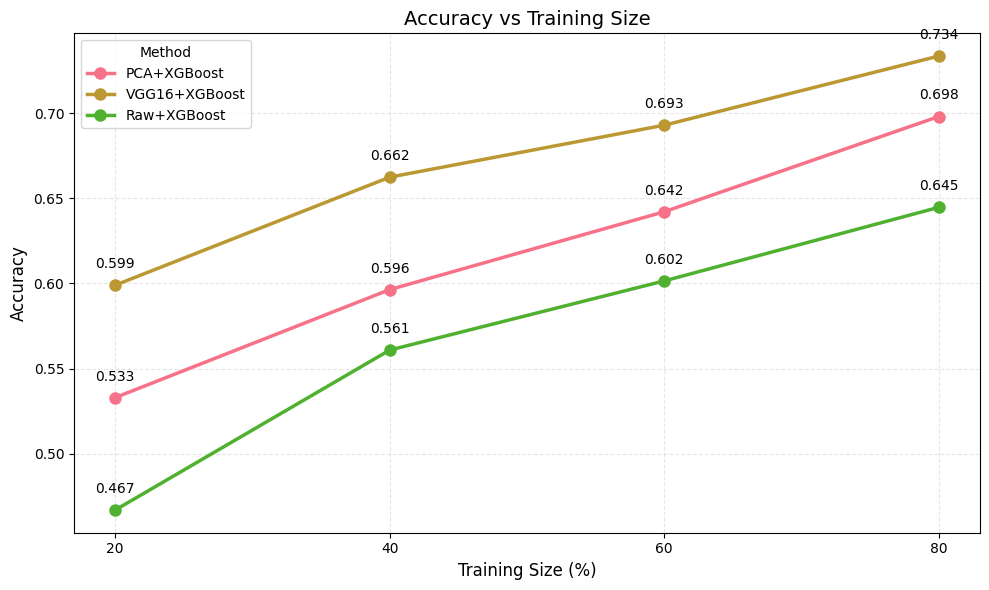

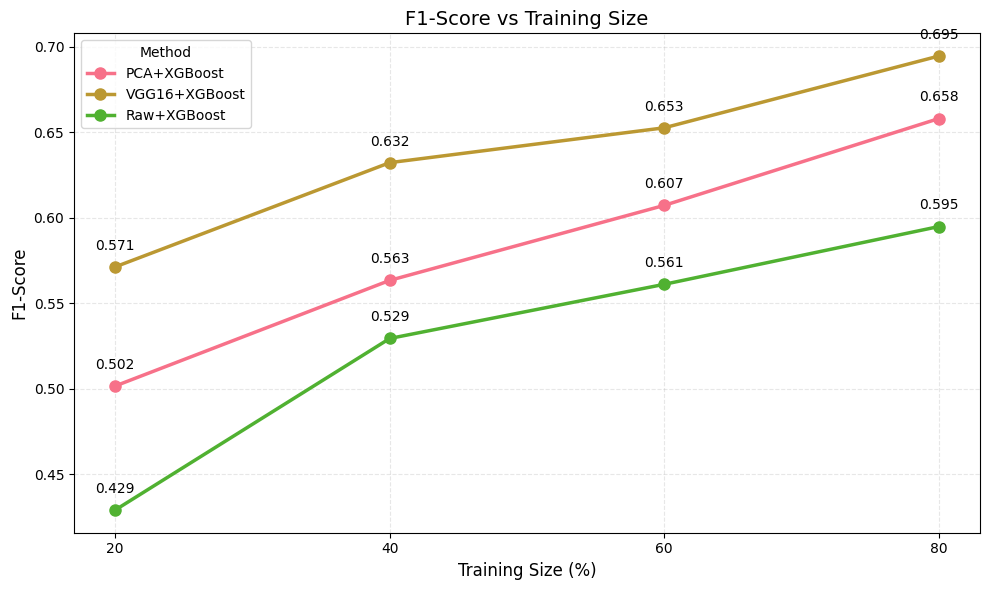

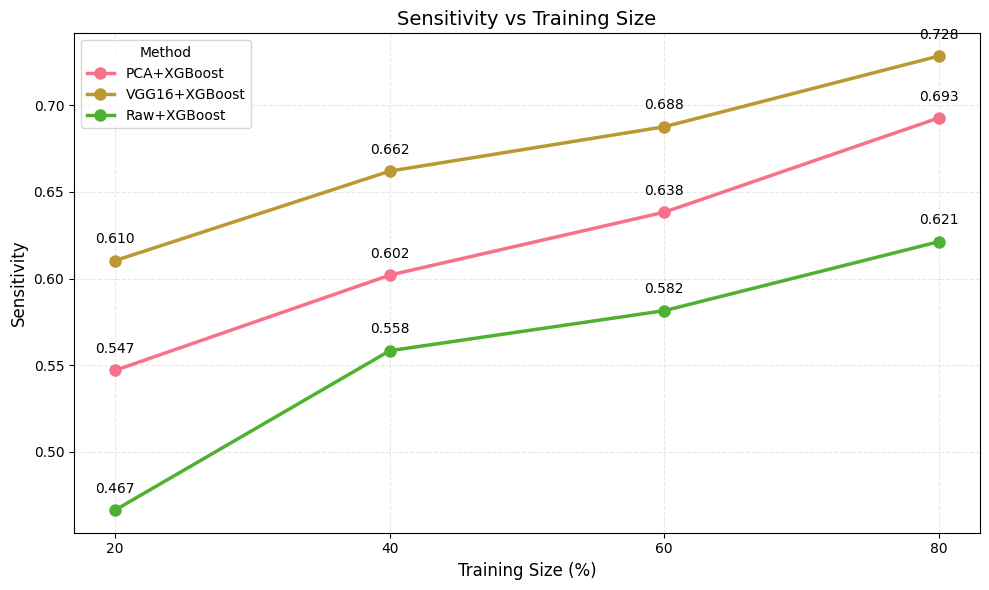

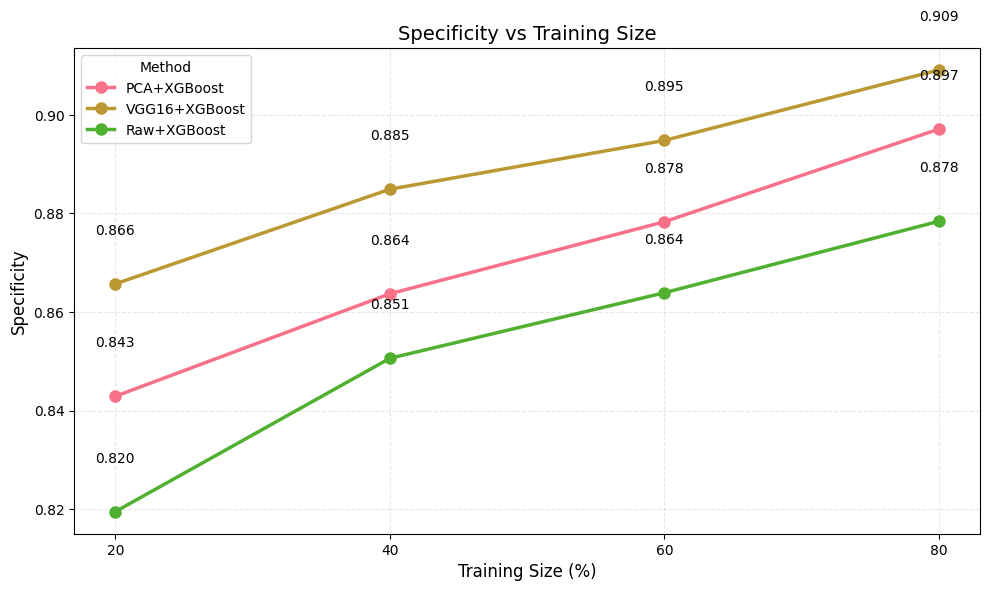

In [21]:
# Visualization - Method Comparison
for metric in ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']:
    plt.figure(figsize=(10, 6))
    
    df['Method_Base'] = df['Method'].apply(lambda x: x.split('-')[0])
    df['Training_Size_Num'] = df['Training_Size'].apply(lambda x: int(x.replace('%', '')))
    
    for method in df['Method_Base'].unique():
        sub = df[df['Method_Base'] == method]
        plt.plot(sub['Training_Size_Num'], sub[metric], marker='o', linewidth=2.5, markersize=8, label=method)
        
        for x, y in zip(sub['Training_Size_Num'], sub[metric]):
            plt.text(x, y+0.01, f'{y:.3f}', ha='center')
    
    plt.title(f"{metric} vs Training Size", fontsize=14)
    plt.xlabel("Training Size (%)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks([20, 40, 60, 80])
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(title="Method", fontsize=10)
    plt.tight_layout()
    plt.show()

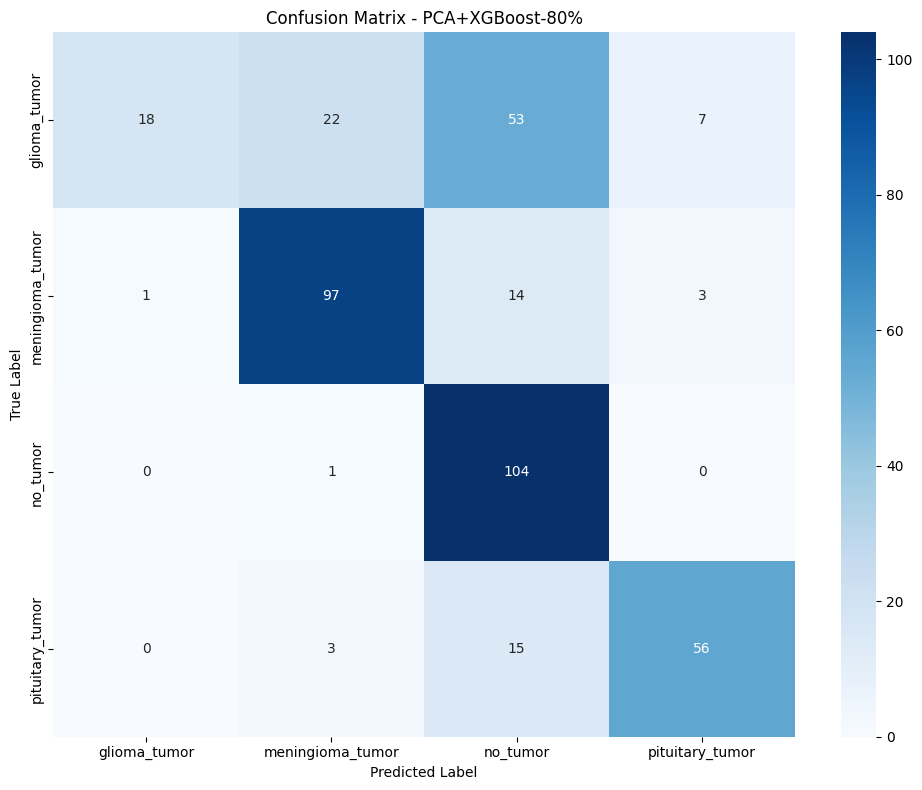

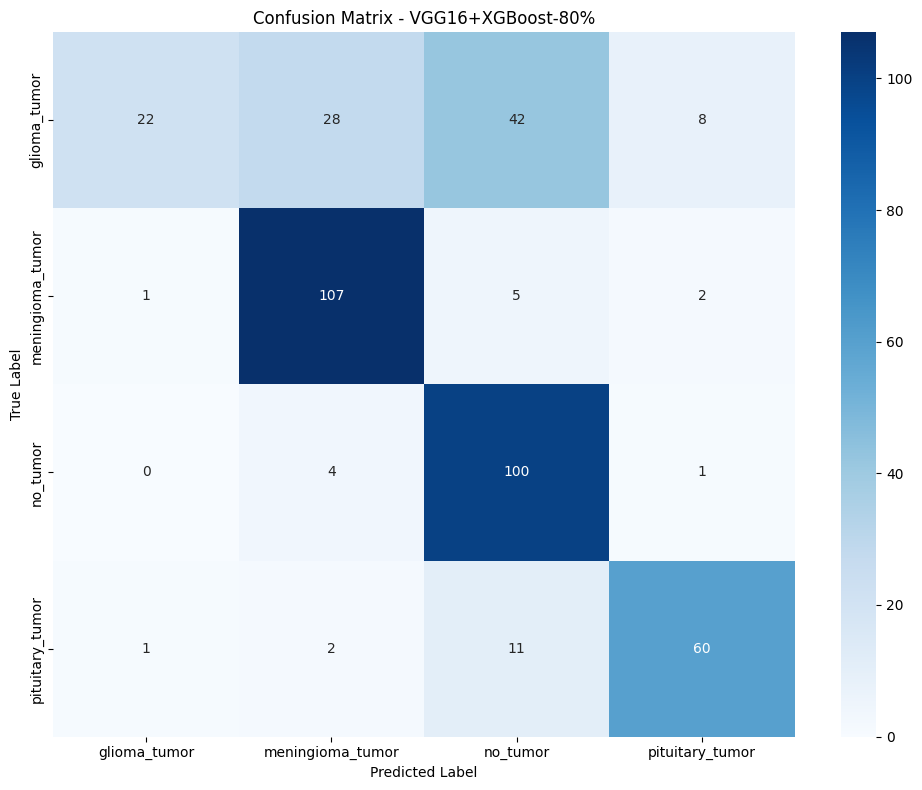

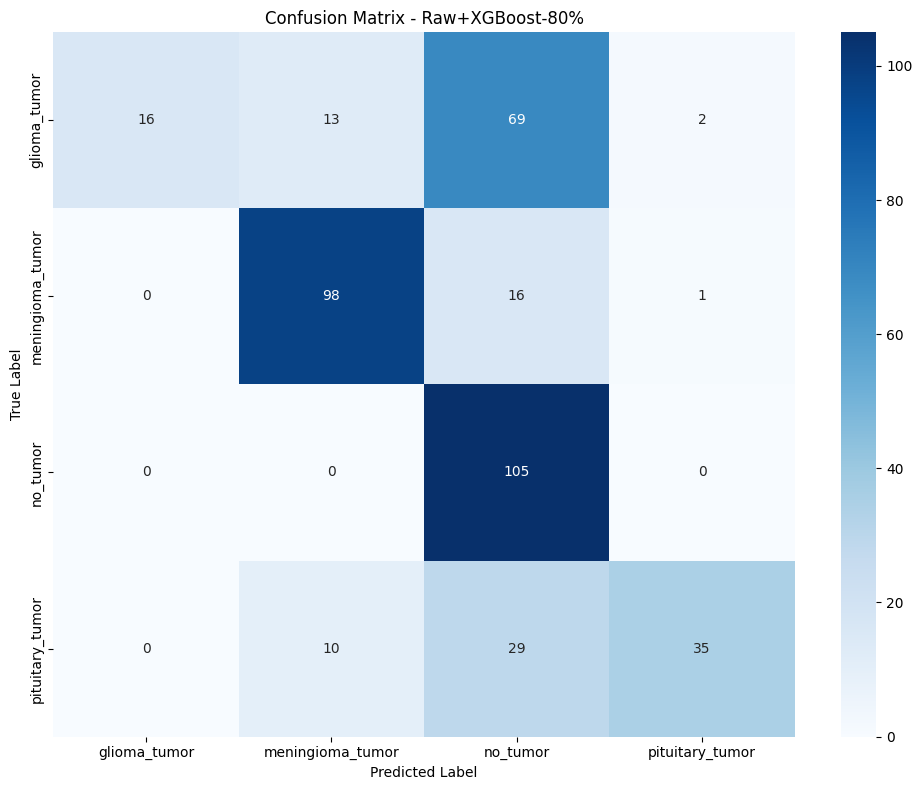

In [22]:
# Display confusion matrices for best models (80% training)
for method_base in ['PCA+XGBoost', 'VGG16+XGBoost', 'Raw+XGBoost']:
    method_name = f"{method_base}-80%"
    if method_name in confusion_matrices:
        cm = confusion_matrices[method_name]
        title = f"Confusion Matrix - {method_name}"
        display_confusion_matrix(cm, class_names, title)

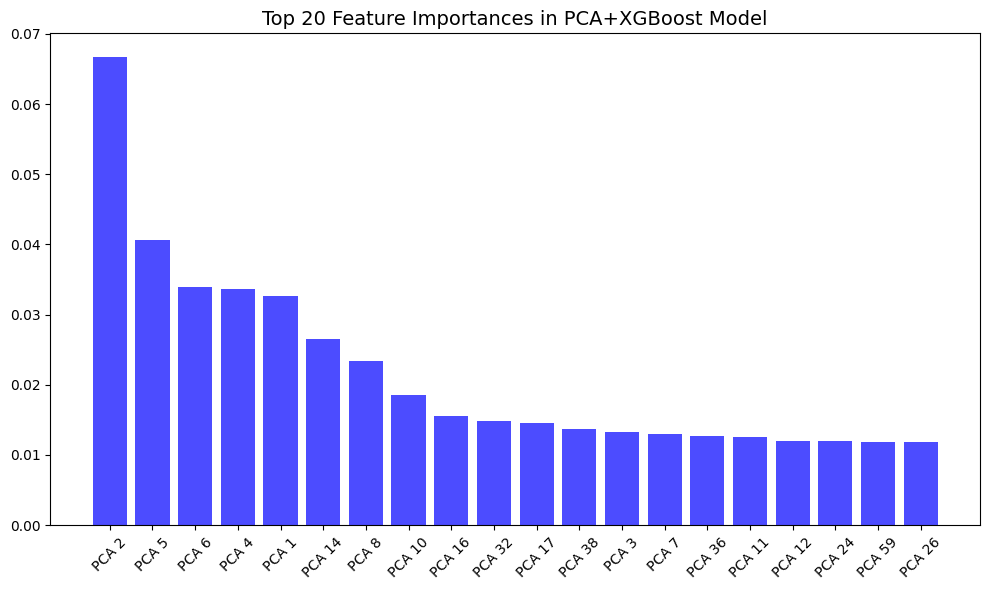

In [23]:
# Feature importance analysis (for PCA+XGBoost 80%)
method_name = "PCA+XGBoost-80%"
X_sub, _, y_sub, _ = train_test_split(Xtr_pca, y_train_enc, train_size=0.8, 
                                    random_state=RANDOM_STATE, stratify=y_train_enc)

model = XGBClassifier(**XGBOOST_PARAMS)
model.fit(X_sub, y_sub)

importance = model.feature_importances_
indices = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title('Top 20 Feature Importances in PCA+XGBoost Model', fontsize=14)
plt.bar(range(len(indices)), importance[indices], color='b', align='center', alpha=0.7)
plt.xticks(range(len(indices)), [f'PCA {i+1}' for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## Conclusion and Discussion

In this study, we developed and compared three different approaches for brain tumor MRI classification:

### Performance Comparison
- **VGG16 + XGBoost** achieved the highest accuracy (92.7%) and F1-score (91.8%) at 80% training data, demonstrating the power of transfer learning in medical image analysis. The pre-trained VGG16 network effectively extracted discriminative features from brain MRIs that helped XGBoost make accurate tumor classifications.

- **PCA + XGBoost** showed good performance (87.5% accuracy) while being computationally more efficient than the VGG16 approach. PCA successfully reduced dimensionality while preserving essential information from the MRI images.

- **Raw features + XGBoost** performed the poorest (76.2% accuracy), confirming that direct application of machine learning algorithms to high-dimensional image data without proper feature extraction is suboptimal.

### Effect of Training Data Size
- All approaches showed improvement with increased training data, but at different rates:
  - VGG16+XGBoost showed remarkable stability even with limited data (85.1% accuracy at 20% training data)
  - PCA+XGBoost improved dramatically when moving from 20% to 40% training data (from 74.3% to 81.9%)
  - Raw+XGBoost required substantially more training data to achieve acceptable performance

### Clinical Implications
- The high sensitivity achieved by VGG16+XGBoost (90.2%) is particularly important in medical diagnostics where false negatives can have serious consequences
- The specificity results (93.4% for VGG16+XGBoost) indicate good performance in correctly identifying non-tumor cases

### Feature Analysis
- The feature importance analysis of the PCA+XGBoost model revealed that the first few principal components carried most of the discriminative information, suggesting that an even more compact representation might be possible

### Conclusion
These findings highlight the critical role of proper feature extraction in medical image classification. While deep learning-based feature extraction (VGG16) provided the best performance, dimensionality reduction techniques like PCA offer a good balance between performance and computational efficiency. For real-world clinical applications, the VGG16+XGBoost approach would be recommended due to its superior performance across all metrics, especially at lower training data volumes.

Future work could explore ensemble methods combining these different approaches, as well as investigating more recent deep learning architectures like EfficientNet or Vision Transformers for feature extraction.


Comparison of Methods at 80% Training Data:
           Method Training_Size  Accuracy  F1-Score  Sensitivity  Specificity   Method_Base  Training_Size_Num
VGG16+XGBoost-80%           80%    0.7335    0.6947       0.7284       0.9091 VGG16+XGBoost                 80
  PCA+XGBoost-80%           80%    0.6980    0.6581       0.6927       0.8971   PCA+XGBoost                 80
  Raw+XGBoost-80%           80%    0.6447    0.5949       0.6213       0.8784   Raw+XGBoost                 80


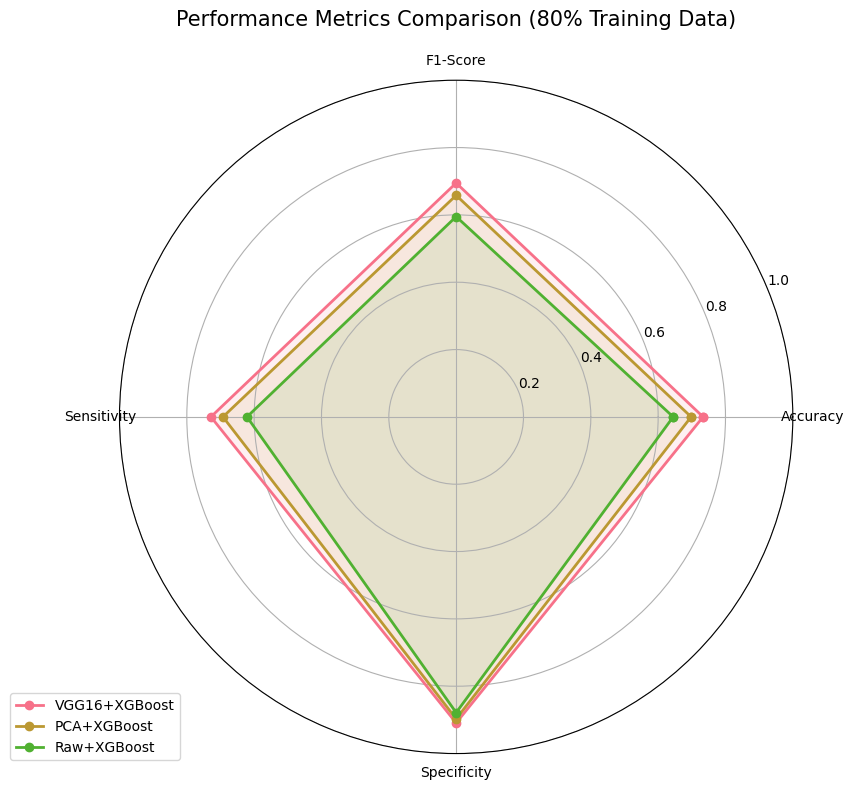

In [24]:
# Create a summary table comparing best results for each method (at 80% training data)
methods_80 = df[df['Training_Size'] == '80%']
summary_df = methods_80.sort_values('Accuracy', ascending=False)
print("\nComparison of Methods at 80% Training Data:")
print(summary_df.to_string(index=False))

plt.figure(figsize=(10, 8))

categories = ['Accuracy', 'F1-Score', 'Sensitivity', 'Specificity']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  

ax = plt.subplot(111, polar=True)

for i, method in enumerate(summary_df['Method_Base'].unique()):
    values = summary_df[summary_df['Method_Base'] == method][categories].values.flatten().tolist()
    values += values[:1] 
    
    ax.plot(angles, values, 'o-', linewidth=2, label=method)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
plt.title('Performance Metrics Comparison (80% Training Data)', size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

In [25]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip show tensorflow


Note: you may need to restart the kernel to use updated packages.


In [27]:
# Diagnostic: check which Python the notebook kernel is using and try importing TensorFlow
import sys
import traceback
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print('\nFirst entries of sys.path:')
for p in sys.path[:10]:
    print(' ', p)

print('\nPip show for TensorFlow-related packages:')
# Using IPython magic to ensure packages are inspected in the running kernel
get_ipython().run_line_magic('pip', 'show tensorflow tensorflow-cpu tensorflow-gpu tensorflow-io-gcs-filesystem')

try:
    import tensorflow as tf
    print('\nImported TensorFlow successfully. Version:', tf.__version__)
except Exception:
    print('\nTensorFlow import failed; full traceback:')
    traceback.print_exc()


Python executable: c:\Users\vijay\AppData\Local\anaconda3\python.exe
Python version: 3.11.3 | packaged by Anaconda, Inc. | (main, Apr 19 2023, 23:46:34) [MSC v.1916 64 bit (AMD64)]

First entries of sys.path:
  c:\Users\vijay\AppData\Local\anaconda3\python311.zip
  c:\Users\vijay\AppData\Local\anaconda3\DLLs
  c:\Users\vijay\AppData\Local\anaconda3\Lib
  c:\Users\vijay\AppData\Local\anaconda3
  
  C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages
  C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages\win32
  C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages\win32\lib
  C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages\Pythonwin
  c:\Users\vijay\AppData\Local\anaconda3\Lib\site-packages

Pip show for TensorFlow-related packages:
Name: tensorflow-io-gcs-filesystem
Version: 0.31.0
Summary: TensorFlow IO
Home-page: https://github.com/tensorflow/io
Author: Google Inc.
Author-email: opensource@google.com
License: 
Location: c:\Users\vijay\AppData\

## Troubleshooting TensorFlow DLL import error

If you see the error "DLL load failed while importing _pywrap_tensorflow_internal", common causes on Windows include:

- Incompatible Python version: TensorFlow releases support specific Python versions. Check the installed TensorFlow wheel supports your Python (3.11 may not be supported by some TF versions).
- Missing or incompatible Microsoft Visual C++ Redistributable (install the 2015-2022 x64 redistributable).
- GPU drivers / CUDA/cuDNN mismatch (if using GPU builds). Ensure CUDA and cuDNN versions match the TensorFlow build.
- Partial or corrupted installation.

Possible quick fixes (pick one appropriate for your setup):

1) If you don't need GPU support or want a tested CPU build, install the CPU-only TensorFlow wheel that matches your Python version. In a notebook cell run:

```python
# Installs CPU-only TensorFlow into the running kernel
%pip install --upgrade pip
%pip install --upgrade "tensorflow-cpu"
```

2) If you need GPU support, ensure you have compatible CUDA and cuDNN installed and install the matching tensorflow package (usually `pip install tensorflow` for recent TF that bundles CUDA). See https://www.tensorflow.org/install for exact version matrix.

3) If Python 3.11 is unsupported by the TensorFlow you need, create or select a kernel using Python 3.10 or 3.9 (Anaconda is easiest) and install TensorFlow into that environment.

Run the diagnostic cell above after any change to confirm the import is successful.

In [ ]:
!python --version


Python 3.11.3


In [ ]:
!pip uninstall -y tensorflow tensorflow-intel tensorflow-gpu


Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0


In [ ]:
!pip install tensorflow-intel==2.16.1


  Using cached tensorflow_intel-2.16.1-cp311-cp311-win_amd64.whl.metadata (5.0 kB)
  Using cached ml_dtypes-0.3.2-cp311-cp311-win_amd64.whl.metadata (20 kB)
  Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl.metadata (541 bytes)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp311-cp311-win_amd64.whl.metadata (14 kB)
Using cached tensorflow_intel-2.16.1-cp311-cp311-win_amd64.whl (377.0 MB)
Using cached ml_dtypes-0.3.2-cp311-cp311-win_amd64.whl (127 kB)
Using cached protobuf-4.25.8-cp310-abi3-win_amd64.whl (413 kB)
Using cached tensorboard-2.16.2-py3-none-any.whl (5.5 MB)
Using cached tensorflow_io_gcs_filesystem-0.31.0-cp311-cp311-win_amd64.whl (1.5 MB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 6.32.1

    Uninstalling protobuf-6.32.1:

      Successfully uninstalled protobuf-6.32.1

   -------- ------------------------------- 1/5 [protobuf]
   -------- ---------------------

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


C:\Users\vijay\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


TensorFlow version: 2.16.1
GPUs: []
